# Pruebas del comportamiento de neuronas individuales

#### 1. Importas las librerías

In [ ]:
from src.Neurona import Neurona
from src.RedDeNeuronas import RedDeNeuronas
from src.Simulador import Simulador
from src.Visualizar import Visualizar


#### 2. Crear las neuronas y cargarlas en un simulador

In [2]:
rs = Neurona.predefinida("rs")
ib = Neurona.predefinida("ib")
ch = Neurona.predefinida("ch")
fs = Neurona.predefinida("fs")
tc = Neurona.predefinida("tc", v_inicial=-63)
tc2 = Neurona.predefinida("tc", v_inicial=-87)
rz = Neurona.predefinida("rz")
lts = Neurona.predefinida("lts")

red = RedDeNeuronas(neuronas={rs: 1, ib: 1, ch: 1, fs: 1, tc: 1, tc2: 1, rz: 1, lts: 1},
                    conexiones=0, backend="numpy", precision=64, sparse=False)

dt = 0.1
pasos = int(200/dt)
corriente = 10
sim = Simulador(dt, mostrar_progreso=True, medir_rendimiento=True, intervalo_rendimiento=100)
vis = Visualizar()


#### 3. Realizar las simulaciones una a una

Simulando: 100%|██████████| 2000/2000 [00:00<00:00, 112927.70pasos/s, CPU=0%, RAM=296MB]  


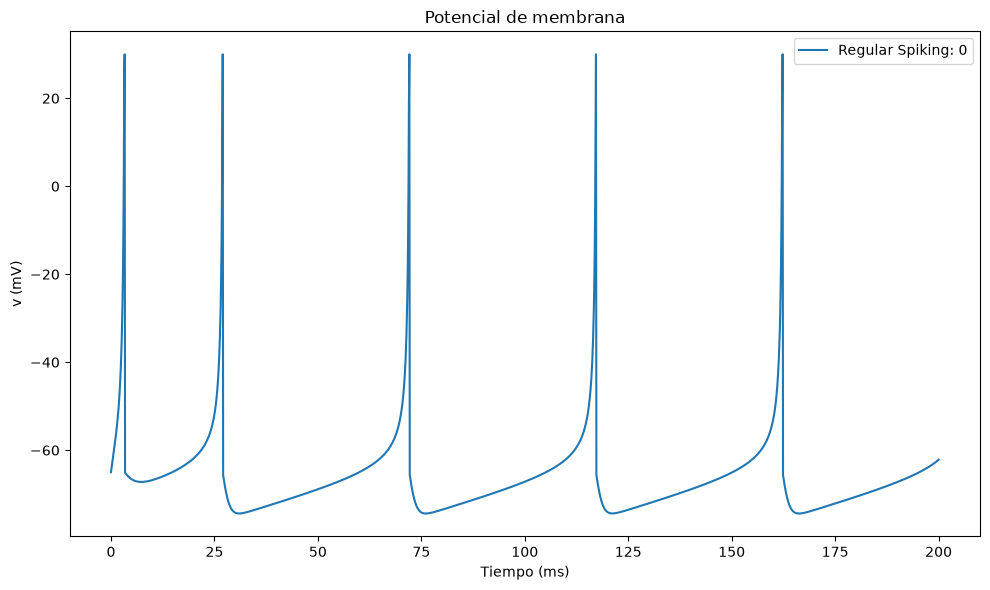

In [3]:
sim.cargar_neurona(rs)
_ = sim.simular(pasos, corriente)
vis.potencial_membrana(historial=sim.historial)
sim.reiniciar()
sim.limpiar_todo()


Simulando: 100%|██████████| 2000/2000 [00:00<00:00, 111836.18pasos/s, CPU=0%, RAM=303MB]   


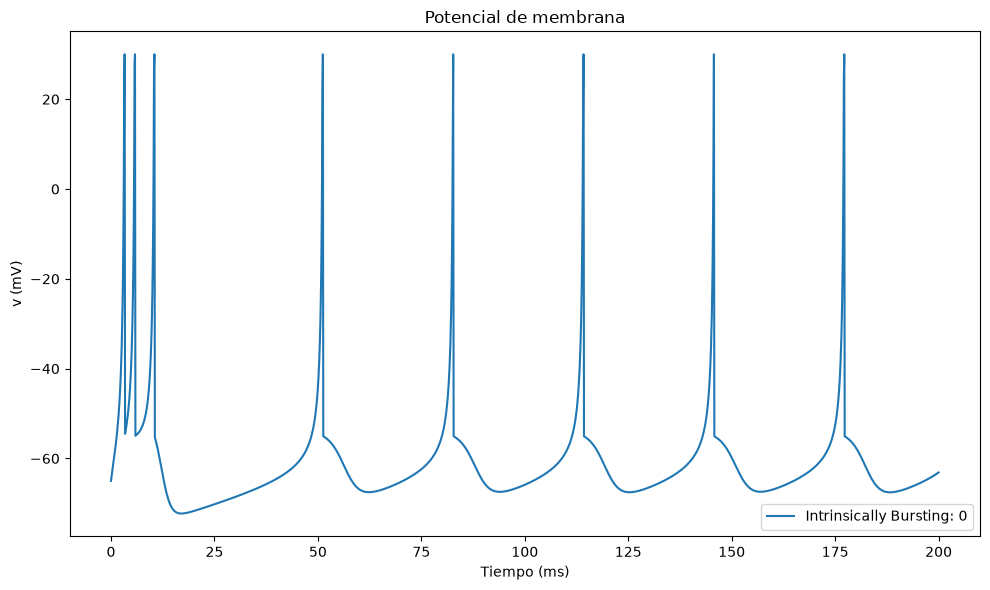

In [4]:
sim.cargar_neurona(ib)
_ = sim.simular(pasos, corriente)
vis.potencial_membrana(historial=sim.historial)
sim.reiniciar()
sim.limpiar_todo()


Simulando: 100%|██████████| 2000/2000 [00:00<00:00, 125277.90pasos/s, CPU=0%, RAM=306MB]   


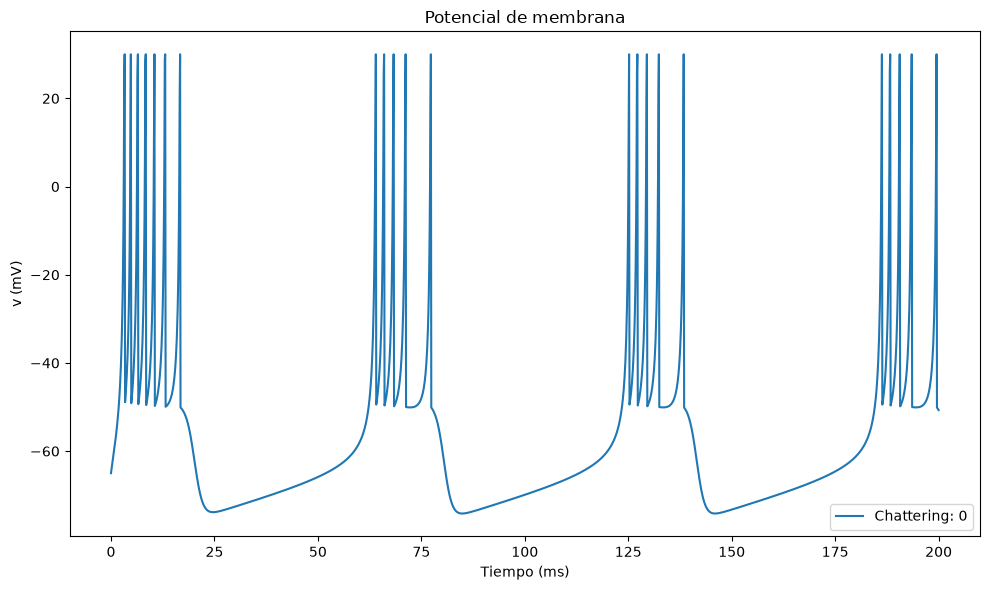

In [5]:
sim.cargar_neurona(ch)
_ = sim.simular(pasos, corriente)
vis.potencial_membrana(historial=sim.historial)
sim.reiniciar()
sim.limpiar_todo()


Simulando: 100%|██████████| 2000/2000 [00:00<00:00, 106737.51pasos/s, CPU=0%, RAM=311MB]  


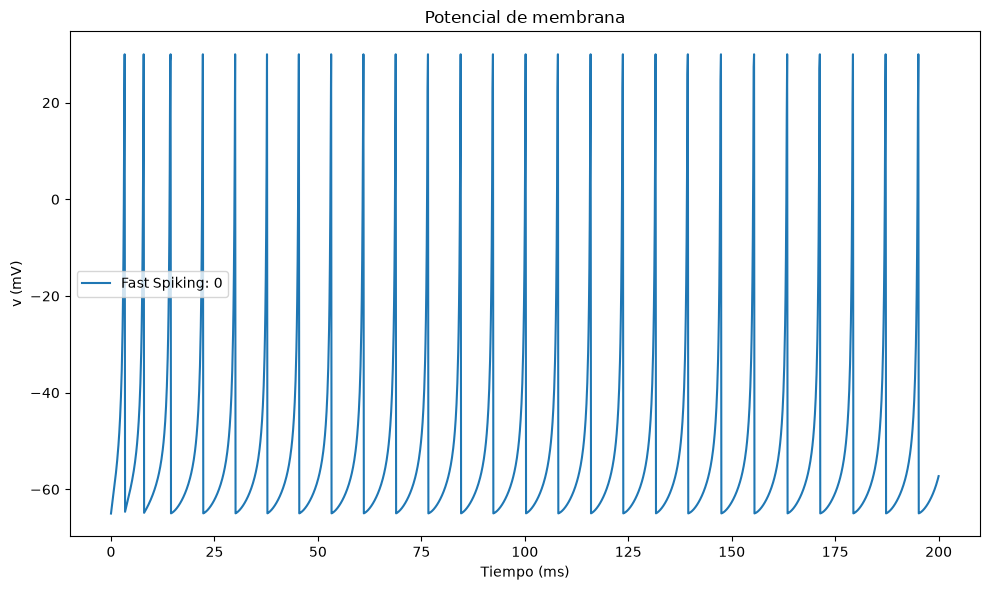

In [6]:
sim.cargar_neurona(fs)
_ = sim.simular(pasos, corriente)
vis.potencial_membrana(historial=sim.historial)
sim.reiniciar()
sim.limpiar_todo()


Simulando: 100%|██████████| 2000/2000 [00:00<00:00, 124341.99pasos/s, CPU=0%, RAM=309MB]  


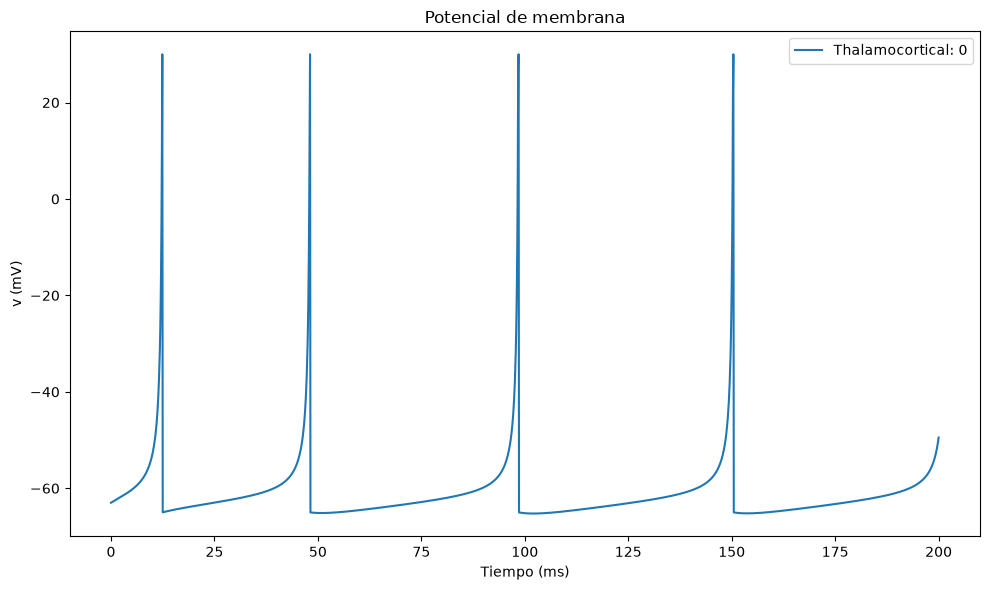

In [7]:
sim.cargar_neurona(tc)
corriente_tc = 1
_ = sim.simular(pasos, corriente_tc)
vis.potencial_membrana(historial=sim.historial)
sim.reiniciar()
sim.limpiar_todo()


Simulando: 100%|██████████| 2000/2000 [00:00<00:00, 130300.38pasos/s, CPU=0%, RAM=312MB]   


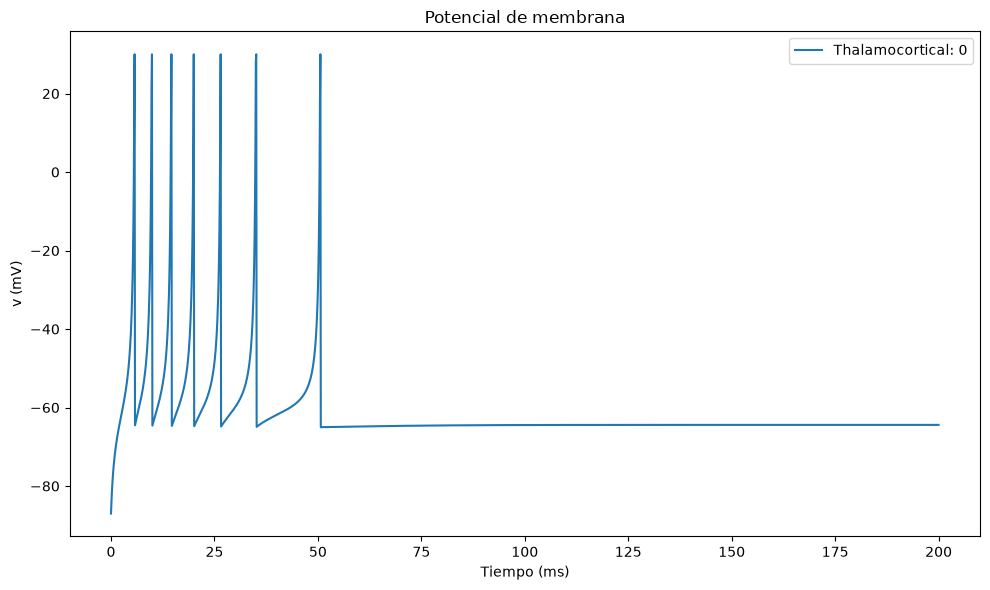

In [8]:
sim.cargar_neurona(tc2)
corriente_tc2 = 0
_ = sim.simular(pasos, corriente_tc2)
vis.potencial_membrana(historial=sim.historial)
sim.reiniciar()
sim.limpiar_todo()


Simulando: 100%|██████████| 2000/2000 [00:00<00:00, 124281.20pasos/s, CPU=0%, RAM=312MB]   


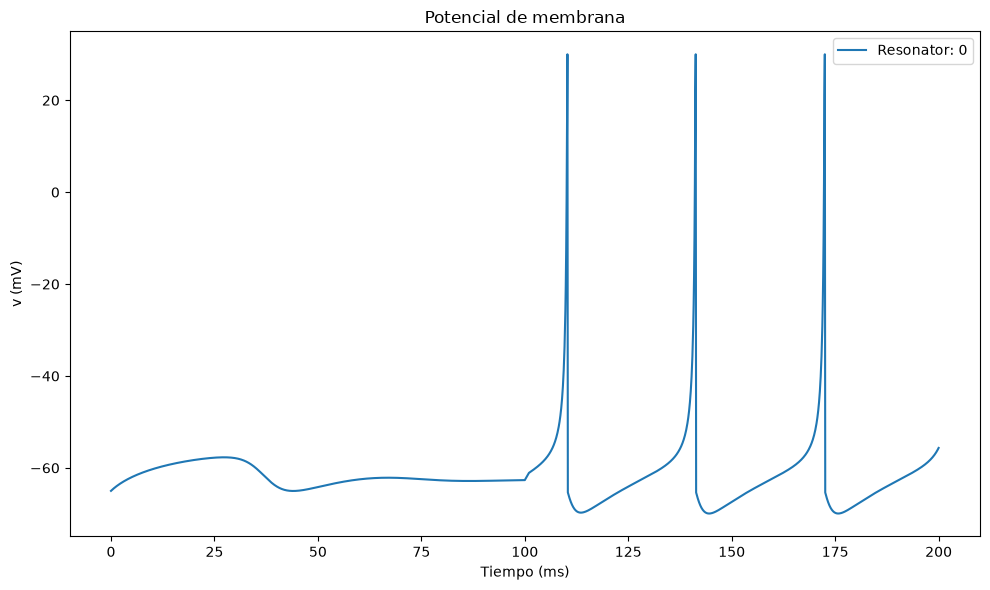

In [9]:
sim.cargar_neurona(rz)
corriente_rz = [-0.045] * (pasos // 2) + [1.5] * 10 + [0.5] * (pasos // 2 - 10)
_ = sim.simular(pasos, corriente_rz)
vis.potencial_membrana(historial=sim.historial)
sim.reiniciar()
sim.limpiar_todo()


Simulando: 100%|██████████| 2000/2000 [00:00<00:00, 120930.82pasos/s, CPU=0%, RAM=315MB]  


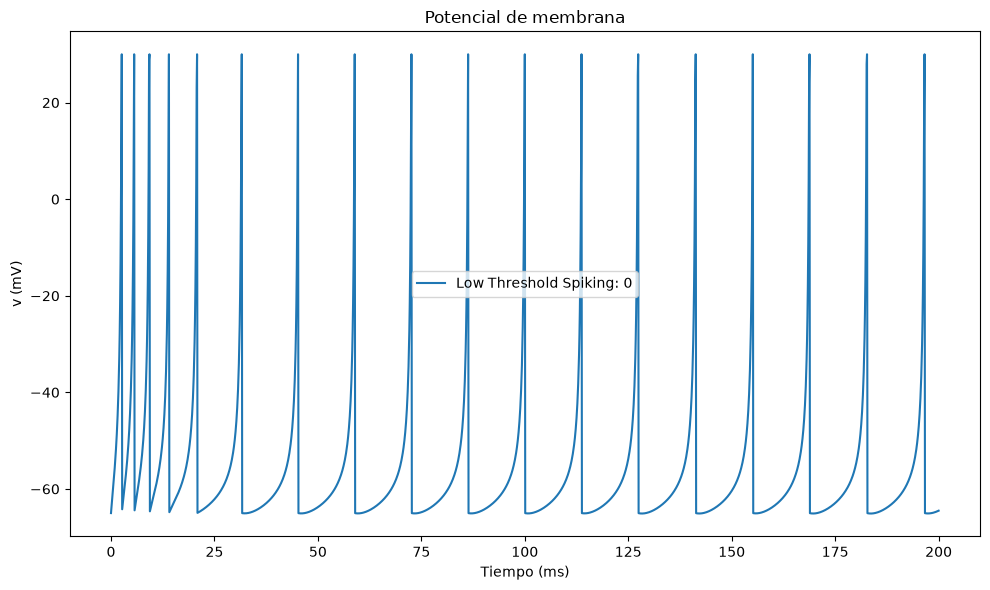

In [10]:
sim.cargar_neurona(lts)
_ = sim.simular(pasos, corriente)
vis.potencial_membrana(historial=sim.historial)
sim.reiniciar()
sim.limpiar_todo()


Simulando: 100%|██████████| 2000/2000 [00:00<00:00, 31632.92pasos/s, CPU=523%, RAM=319MB]


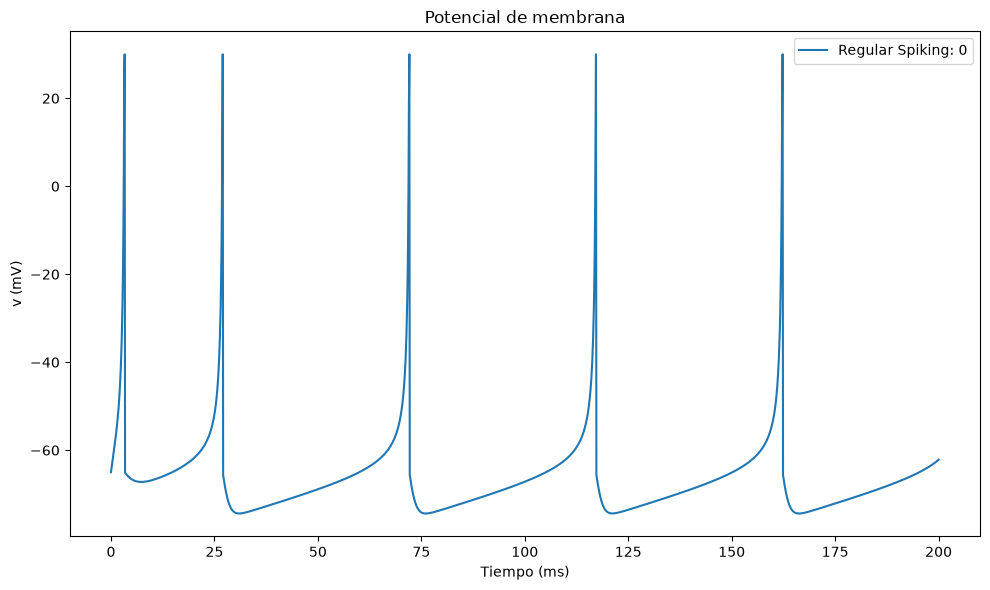

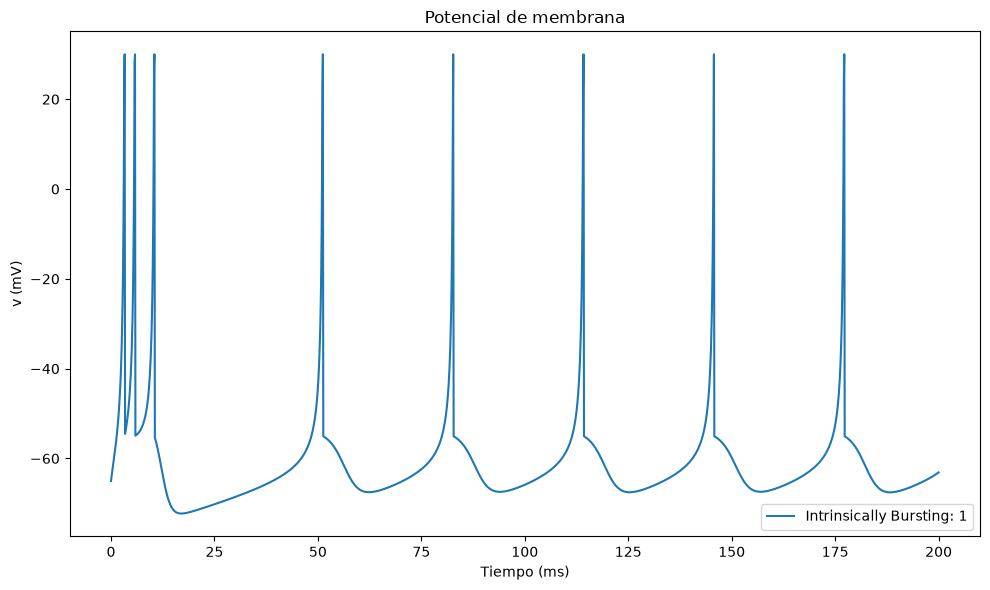

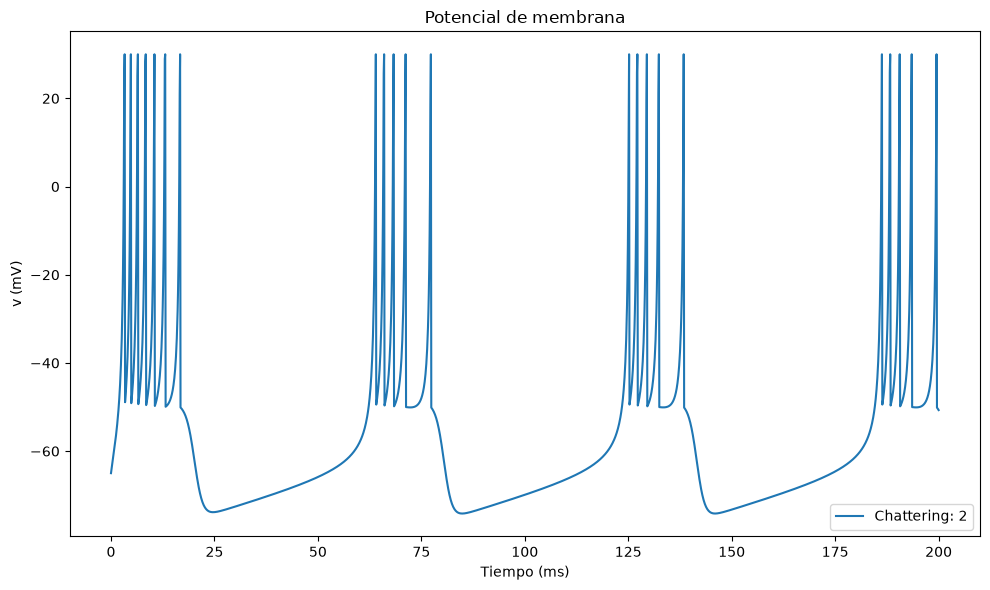

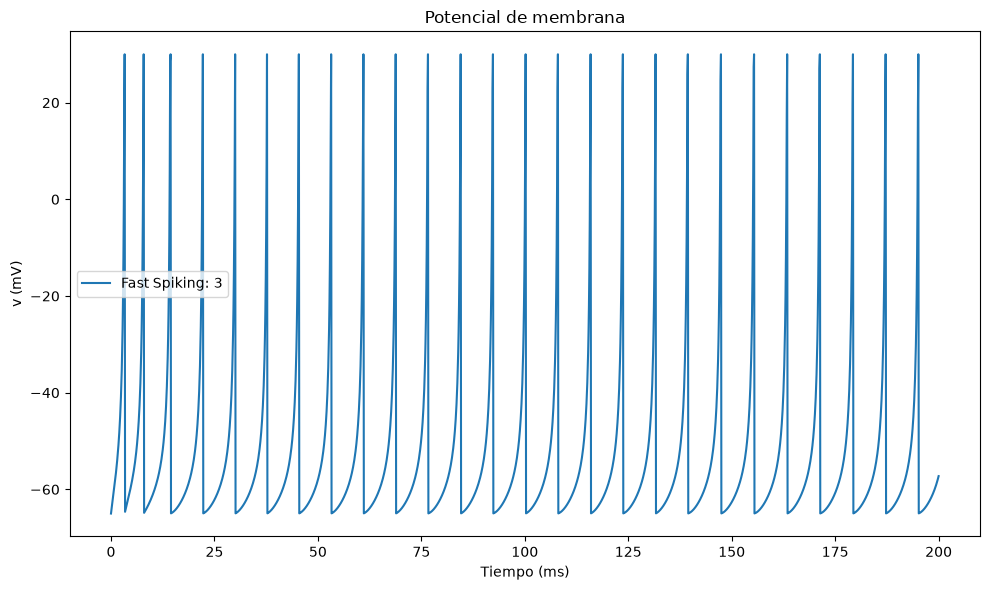

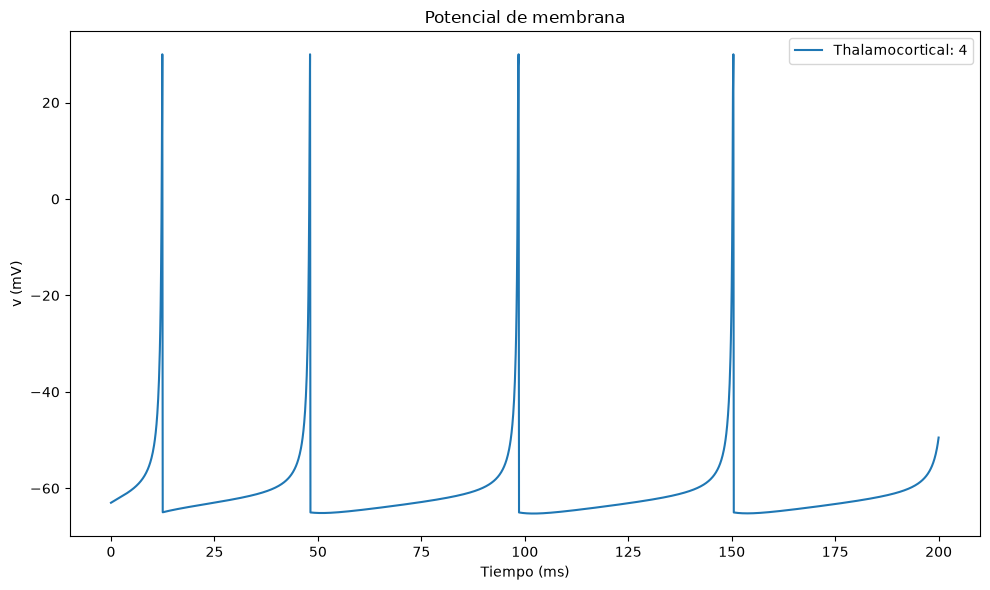

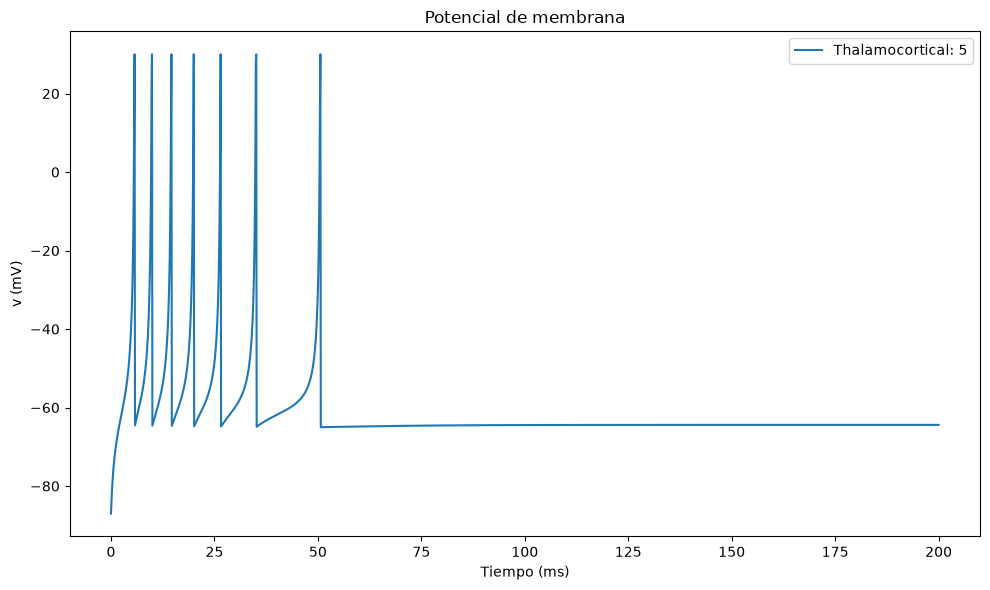

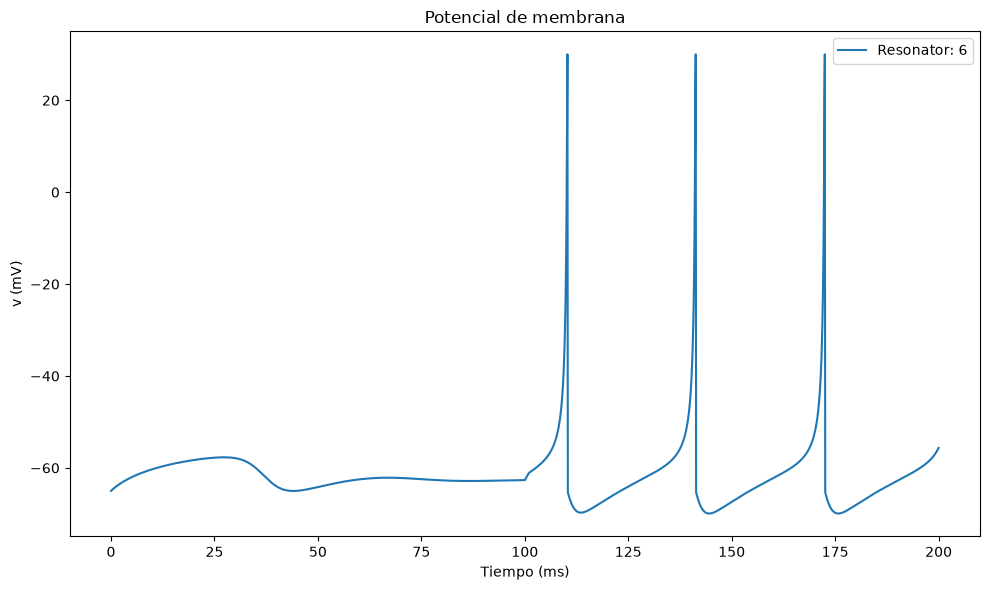

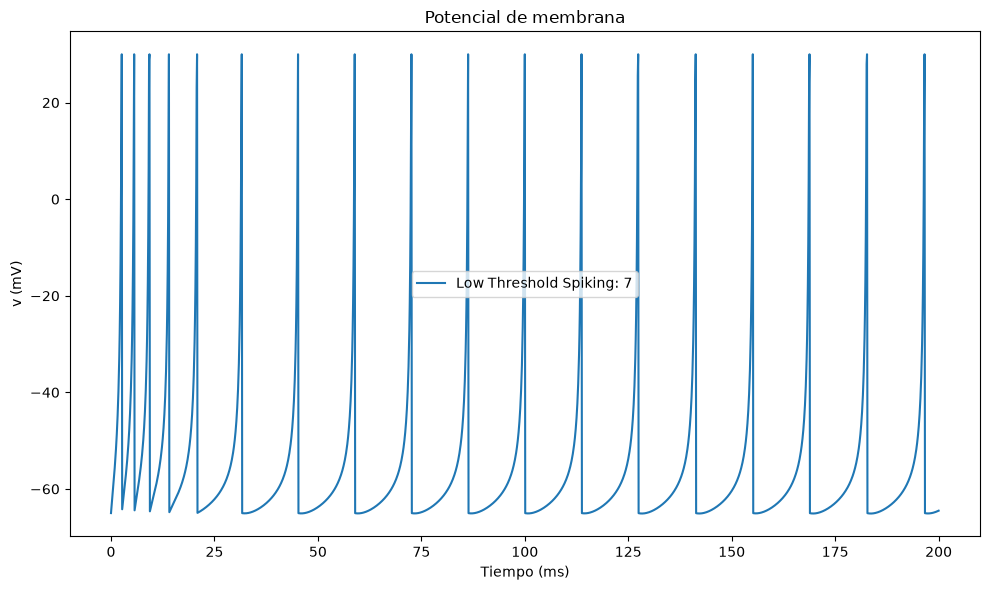

In [11]:
sim.cargar_red(red)
corriente_rz = [-0.045] * (pasos // 2) + [1.5] * 10 + [0.5] * (pasos // 2 - 10)
corriente_red = []
for i in range(pasos):
    corriente_red.append([corriente] * 4 + [1] + [0] + [corriente_rz[i]] + [corriente])
_ = sim.simular(pasos, corriente_red)
vis.cargar_historial(historial=sim.historial)
for i in range(8):
    vis.potencial_membrana(neuronas=i)
sim.reiniciar()
sim.limpiar_todo()
